In [2]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

### Channel labels

In [3]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [ ]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [5]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [6]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

### Select bursts corresponding to C3/C4 and all STN contacts

In [7]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

### Train a logistic regression on the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN that undergo a gcPCA 

In [8]:
burst_times = all_bursts['waveform_times'] * 1000 

In [9]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [ ]:
where = c_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.

In [ ]:
# Subject-level classification using Logistic Regression with K-Fold Cross-Validation

n_splits = 10           # Number of folds for cross-validation
n_bins = 4              # Number of bins to use for each gcPC
n_gcPCs = np.arange(0, 10, 1)  # Half of the gcPCs to consider (from 0 to 10, inclusive thanks to the way the loop is written)
# cols = [0, 1, -2, -1]   # List of gcPC columns to consider

accuracy = []
var = []
for n_gcPC in n_gcPCs+1:
    null_and_positive = np.arange(0, n_gcPC + 1, 1)
    negative = np.arange(-n_gcPC - 1, 0, 1)
    cols = np.concatenate([null_and_positive, negative])
    print(cols)

    subjects_score = []
    for subject in subjects:
        subj_idx = (all_bursts['subject']==subject) & where
        trials = np.unique(all_bursts['trial'][subj_idx])

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
        
        fold_score = []
        for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
            train_bursts_idx = np.isin(all_bursts['trial'], trials[train_index]) & subj_idx
            train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
            train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')
                
            # GCPCA model trained only on test set bursts of the current subject
            gcpca_model = gcPCA(method='v4', normalize_flag=False)                                                      # gcPCA model creation
            gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
            
            # Project all bursts of the current subject into PC space using the trained model
            all_scores = scaled_waveforms@gcpca_model.loadings_
            
            X = []
            y = []
            pc_bin_lims = np.zeros((len(cols), n_bins + 1))
            # Build trial-level feature matrix X and matching label vector y
            for trial in trials:
                # For each trial, count how many bursts fall into each bin for the current gcPC
                burst_idx = subj_idx & (all_bursts["trial"]==trial)
                label = np.unique(all_bursts["med"][burst_idx])[0]

                row = []
                for i, col in enumerate(cols):
                    # Compute percentile edges for each gcPC of interest across all bursts 
                    pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

                    for idx in range(len(pc_bin_lims[i, :]) - 1):
                        # Count bursts whose gcPC score falls within the current percentile bin
                        count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                            (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                        row.append(count)

                X.append(row)
                y.append(0 if label=='OFF' else 1)

            X = np.array(X)
            y = np.array(y)

            model = LOR()
            model = model.fit(X[train_index, :], y[train_index])
            y_pred = model.predict(X[test_index, :])

            score = 1 - np.sqrt(np.mean((y[test_index] - y_pred) ** 2))
            print(f'Subject {subject} fold {fold_idx}: Score = {score:.3f}')
            fold_score.append(score)

        print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
        subjects_score.append(np.mean(fold_score))

    print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')
    accuracy.append(np.mean(subjects_score))
    var.append(np.std(subjects_score))
    print(n_gcPC)
    print("\n")

[ 0  1 -2 -1]
Subject s02 fold 0: Score = 0.500


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 1: Score = 0.500
Subject s02 fold 2: Score = 0.134


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 3: Score = 0.500
Subject s02 fold 4: Score = 0.134


...

Subject s18 fold 7: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 8: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 9: Score = 0.184
Subject s18: Mean Score = 0.918 ± 0.245
Overall Mean Score across subjects: 0.843 ± 0.144
10




Text(0.5, 1.0, '$\\mathrm{Within\\ subject\\ -\\ f(2\\times n}$_$\\mathrm{gcPCas)\\ =\\ Accuracy \\pm std}$')

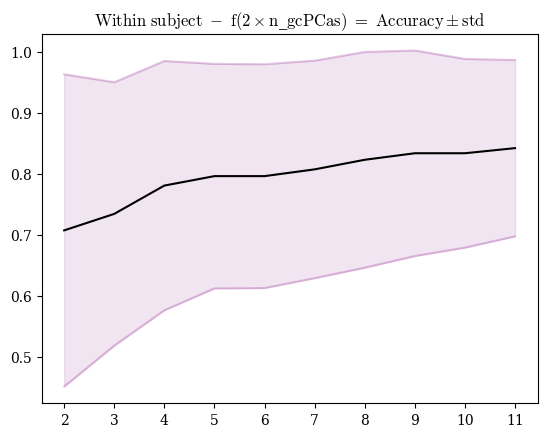

In [ ]:
# Plotting accuracy with error bars representing the standard deviation across subjects as a function of half the number of gcPCs included in the feature set

upper = np.array(accuracy) + np.array(var)
lower = np.array(accuracy) - np.array(var)
plt.plot(accuracy, color='black')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple',alpha=0.2)
plt.fill_between(np.arange(len(accuracy)), lower, upper, color='purple', alpha=0.1)
plt.xticks(ticks=np.arange(len(accuracy)), labels=[i + 2 for i, _ in enumerate(accuracy)])
plt.title(r"$\mathrm{Within\ subject\ -\ f(2\times n}$_$\mathrm{gcPCas)\ =\ Accuracy \pm std}$")

In [ ]:
# Subject-level classification using Logistic Regression with K-Fold Cross-Validation for a fixed number of gcPCs

n_splits = 10  # Number of folds for cross-validation
n_bins = 4  # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]  # List of gcPC columns to consider

subjects_score = []
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject) & stn_idx
    trials = np.unique(all_bursts['trial'][subj_idx])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
    
    fold_score = []
    for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
        train_bursts_idx = np.isin(all_bursts['trial'], trials[train_index]) & subj_idx
        train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')
            
        # GCPCA model trained only on test set bursts of the current subject
        gcpca_model = gcPCA(method='v4', normalize_flag=False)                                # gcPCA model creation
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
    
        # Project all bursts of the current subject into PC space using the trained model
        all_scores = scaled_waveforms@gcpca_model.loadings_
        
        X = []
        y = []
        pc_bin_lims = np.zeros((len(cols), n_bins + 1))

        # Build trial-level feature matrix X and matching label vector y
        for trial in trials:
            # For each trial, count how many bursts fall into each bin for the current gcPC
            burst_idx = subj_idx & (all_bursts["trial"]==trial)
            label = np.unique(all_bursts["med"][burst_idx])[0]

            row = []
            for i, col in enumerate(cols):
                # Compute percentile edges for each gcPC of interest across all bursts 
                pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

                for idx in range(len(pc_bin_lims[i, :]) - 1):
                    # Count bursts whose gcPC score falls within the current percentile bin
                    count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                        (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                    row.append(count)

            X.append(row)
            y.append(0 if label=='OFF' else 1)

        X = np.array(X)
        y = np.array(y)

        model = LOR()
        model = model.fit(X[train_index, :], y[train_index])
        y_pred = model.predict(X[test_index, :])

        score = 1 - np.sqrt(np.mean((y[test_index] - y_pred) ** 2))
        print(f'Subject {subject} fold {fold_idx}: Score = {score:.3f}')
        fold_score.append(score)

    print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
    subjects_score.append(np.mean(fold_score))

print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')

Subject s02 fold 0: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 1: Score = 1.000
Subject s02 fold 2: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 3: Score = 1.000
Subject s02 fold 4: Score = 1.000


...

Subject s18 fold 5: Score = 1.000
Subject s18 fold 6: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 7: Score = 1.000
Subject s18 fold 8: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 9: Score = 1.000
Subject s18: Mean Score = 1.000 ± 0.000
Overall Mean Score across subjects: 0.960 ± 0.076
